<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/TETESAN_MINYAK_MILIKAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== HASIL MUATAN (C) ===
              qf            qr          qavg
0   4.167660e-19  8.438802e-19  6.303231e-19
1   5.467422e-19  5.500493e-19  5.483957e-19
2   1.242870e-18  1.091263e-18  1.167067e-18
3   2.757723e-18  2.883038e-18  2.820380e-18
4   3.246252e-19  4.957857e-19  4.102055e-19
5   8.417614e-19  1.109403e-18  9.755824e-19
6   1.265990e-18  1.944805e-18  1.605398e-18
7   1.111232e-18  1.100045e-18  1.105638e-18
8   1.797787e-18  1.772285e-18  1.785036e-18
9   1.417712e-18  1.419046e-18  1.418379e-18
10  7.976230e-19  8.118728e-19  8.047479e-19
11  1.461097e-18  1.424101e-18  1.442599e-18
12  1.455076e-18  1.454956e-18  1.455016e-18
13  1.143504e-18  1.106299e-18  1.124902e-18
14  1.775958e-18  1.731701e-18  1.753829e-18
15  1.257411e-18  1.289690e-18  1.273551e-18
16  6.411659e-19  6.395297e-19  6.403478e-19
17  9.514315e-19  9.769498e-19  9.641906e-19
18  1.621589e-18  1.573580e-18  1.597584e-18
19  1.099602e-18  1.133983e-18  1.116793e-18

Estimasi e (histogram) = 1.64

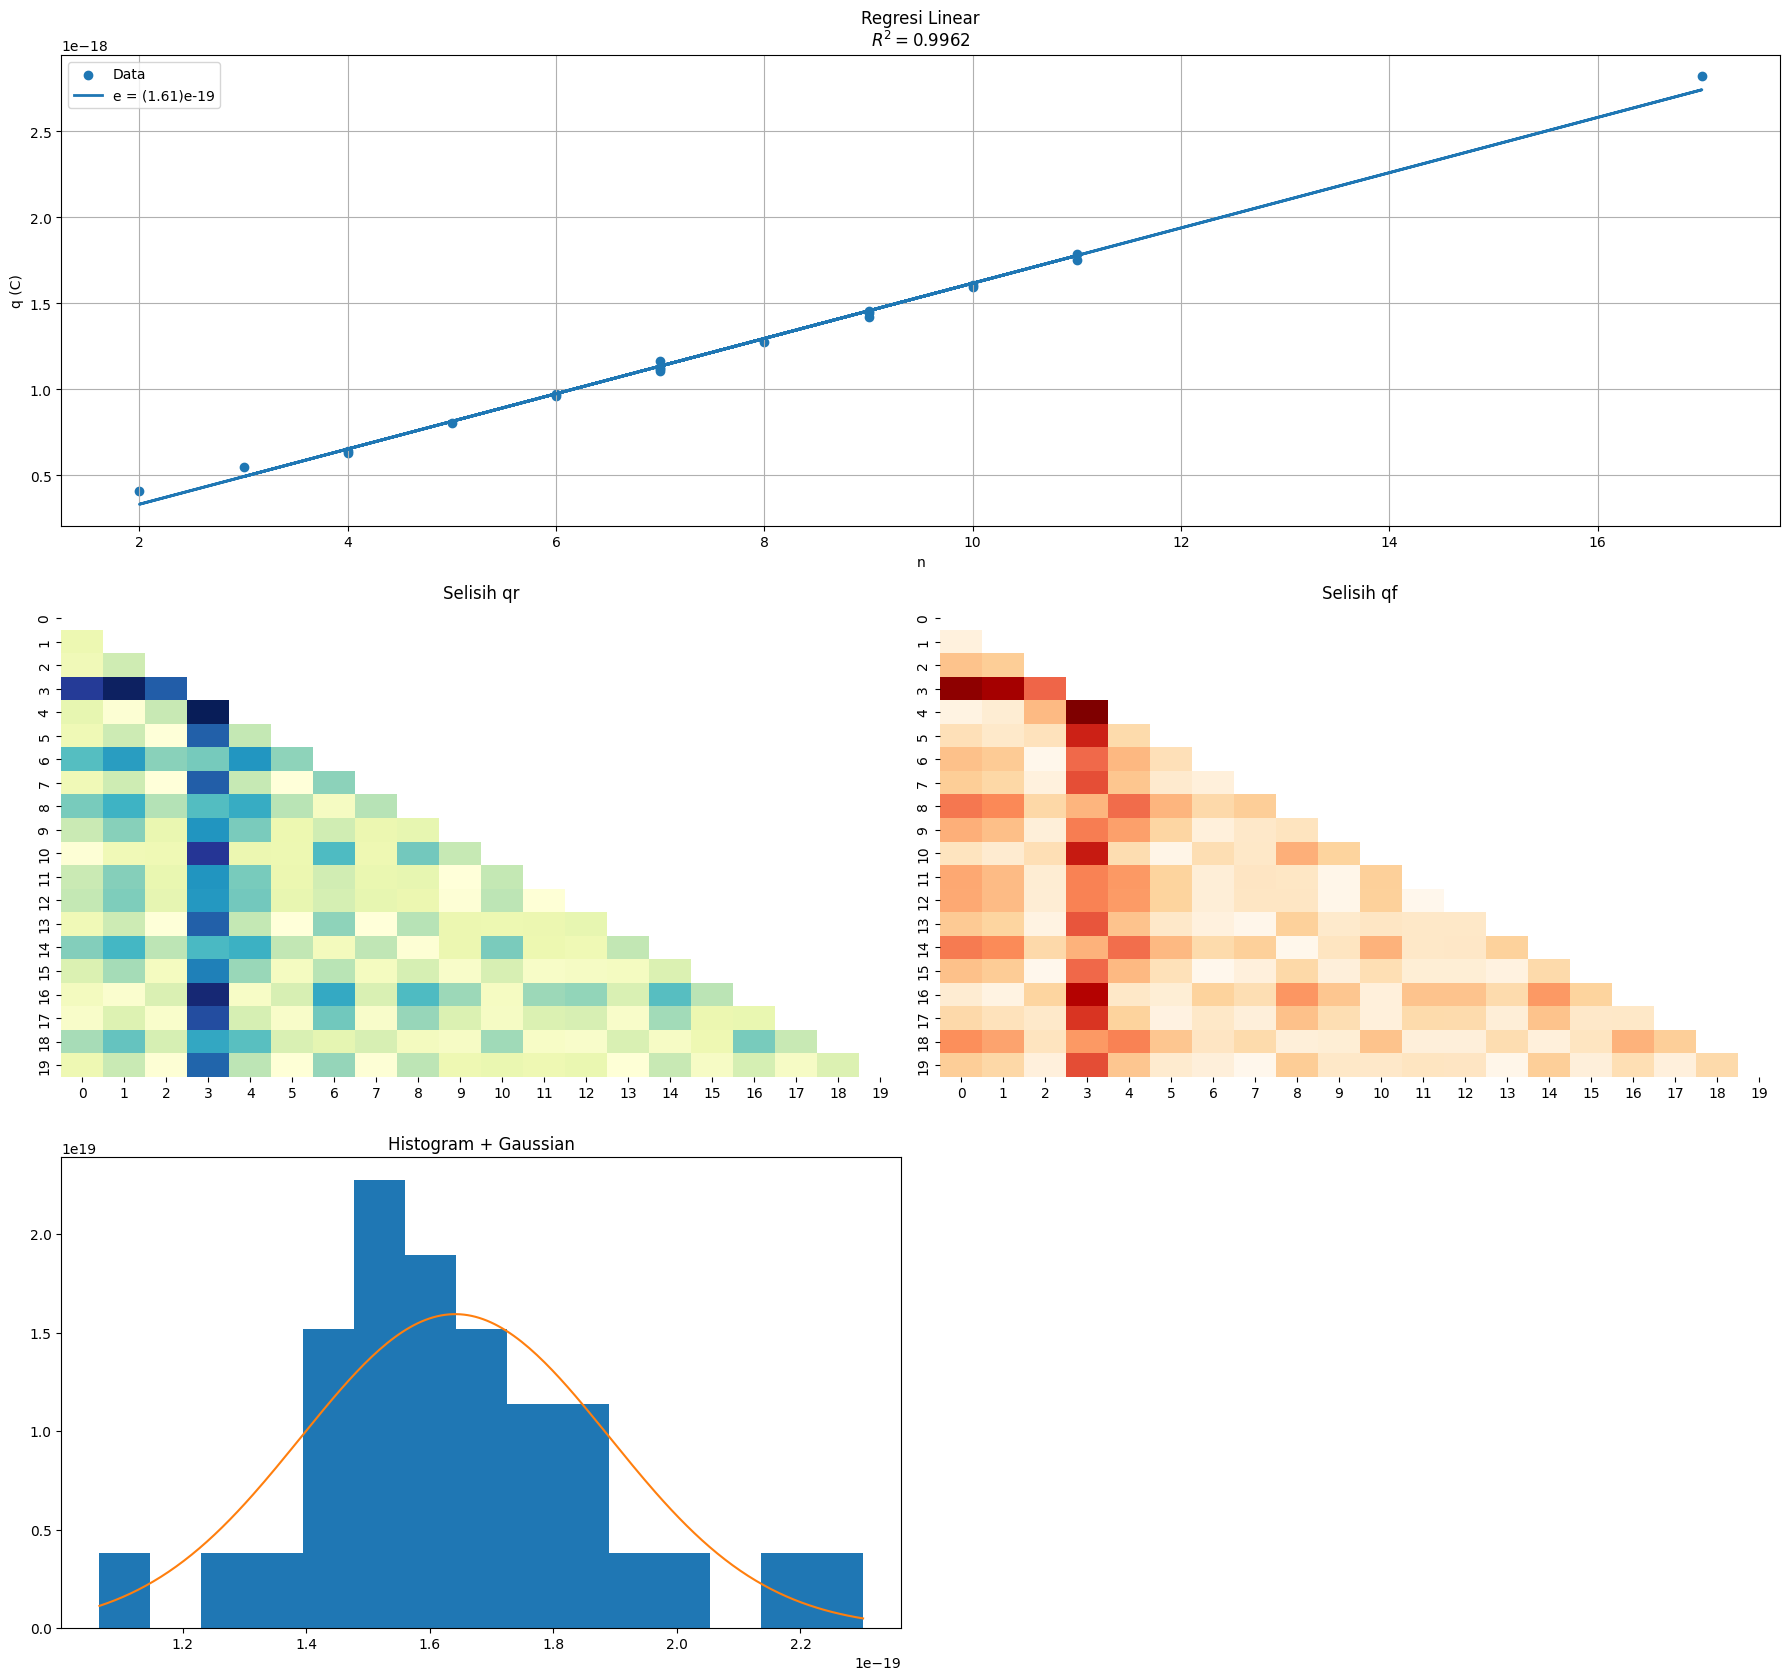

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

# ================================
# DATA
# ================================
data = {
    'td': [13.541,12.749,7.568,5.105,13.796,7.297,7.175,12.13,11.72,16.65,12.45,15.75,6.61,18.81,6.83,6.77,12.33,20.27,9.37,19.96],
    'tu': [7.12,16.89,11.87,3.668,11.99,9.722,4.576,13.85,13.57,20.83,17.9,33.79,13.75,26.57,10.56,41.11,23.23,18.11,30.27,41.1],
    'Us': [314,262,252,205,392,393,268,138.9,90.4,67.7,186.1,71.4,263.7,69.9,205.7,294.4,234.9,75.1,140.2,66.5],
    'Ur': [450,457,470,469,552,522,448,263.2,170.9,121.7,310,107.4,390.5,123.4,347.4,334.3,360.5,155,189.2,95.8]
}

df = pd.DataFrame(data)

# ================================
# KONSTANTA
# ================================
d = 1e-3
l = 6e-3
eta = 1.85e-5
rho_o = 875
rho_f = 1.29
g = 9.81

# ================================
# KECEPATAN
# ================================
df['vd'] = d / df['td']
df['vu'] = d / df['tu']

# ================================
# JARI-JARI
# ================================
df['r'] = np.sqrt((9 * eta * df['vd']) / (2 * g * (rho_o - rho_f)))

# ================================
# MUATAN
# ================================
df['qf'] = (18 * np.pi * eta * l * df['vd'] / df['Us']) * np.sqrt((eta * df['vd']) / (2 * g * (rho_o - rho_f)))
df['qr'] = (18 * np.pi * eta * l * (df['vd'] + df['vu']) / df['Ur']) * np.sqrt((eta * df['vd']) / (2 * g * (rho_o - rho_f)))
df['qavg'] = (df['qf'] + df['qr']) / 2

print("=== HASIL MUATAN (C) ===")
print(df[['qf','qr','qavg']])

# ================================
# PAIRWISE DIFFERENCE → cari e
# ================================
diffs = []
vals = df['qavg'].values

for i in range(len(vals)):
    for j in range(i):
        diffs.append(abs(vals[i] - vals[j]))

diffs = np.array(diffs)

# FILTER puncak pertama
filtered = diffs[(diffs > 1e-19) & (diffs < 2.5e-19)]

# Gaussian fit
mu, std = stats.norm.fit(filtered)

print("\nEstimasi e (histogram) =", mu)

# ================================
# BUAT n & e_est
# ================================
df['n'] = np.round(df['qavg'] / mu)

# hindari n=0
df = df[df['n'] != 0]

df['e_est'] = df['qavg'] / df['n']

# ================================
# REGRESI LINEAR
# ================================
X_reg = df['n'].values.reshape(-1, 1)
y_reg = df['qavg'].values

model = LinearRegression().fit(X_reg, y_reg)
y_pred = model.predict(X_reg)
r_sq = model.score(X_reg, y_reg)

# ================================
# OUTPUT
# ================================
print("\n--- HASIL PERHITUNGAN ---")
print(df[['qf', 'qr', 'qavg', 'n', 'e_est']].to_string())
print(f"\nGradien (e estimasi): {model.coef_[0]:.4e} C")
print(f"R-squared: {r_sq:.4f}")

# ================================
# VISUALISASI
# ================================
fig = plt.figure(figsize=(18, 22))

# A. Regresi Linear
ax1 = plt.subplot(4, 1, 1)
ax1.scatter(df['n'], df['qavg'], label='Data')
ax1.plot(df['n'], y_pred, linewidth=2,
         label=f'e = ({model.coef_[0]/1e-19:.2f})e-19')
ax1.set_title(f'Regresi Linear\n$R^2 = {r_sq:.4f}$')
ax1.set_xlabel('n')
ax1.set_ylabel('q (C)')
ax1.grid()
ax1.legend()

# B. Matriks Rising
ax2 = plt.subplot(4, 2, 3)
mat_r = np.abs(np.subtract.outer(df['qr'].values, df['qr'].values))
mask = np.triu(np.ones_like(mat_r, dtype=bool))
sns.heatmap(mat_r, mask=mask, cmap='YlGnBu', ax=ax2, cbar=False)
ax2.set_title('Selisih qr')

# C. Matriks Floating
ax3 = plt.subplot(4, 2, 4)
mat_f = np.abs(np.subtract.outer(df['qf'].values, df['qf'].values))
sns.heatmap(mat_f, mask=mask, cmap='OrRd', ax=ax3, cbar=False)
ax3.set_title('Selisih qf')

# D. Histogram Gaussian
ax4 = plt.subplot(4, 2, 5)
ax4.hist(filtered, bins=15, density=True)
x = np.linspace(min(filtered), max(filtered), 200)
ax4.plot(x, stats.norm.pdf(x, mu, std))
ax4.set_title('Histogram + Gaussian')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from math import pi

# Konstanta
eta = 1.81e-5  # Ns/m^2
rho_minyak = 875.3  # kg/m^3
rho_udara = 1.29  # kg/m^3
g = 9.8  # m/s^2
e = 1.602e-19  # C (muatan elementer)
d = 0.006  # m

# Data eksperimen
data = {
    'U_F': [322, 292, 368, 323, 345, 369, 392, 357, 304, 382, 256.00, 455.00, 354.00, 353.00, 474.00, 504.00, 416.00, 322.00, 388.00, 453.00, 237.00, 475.00, 331.00, 291.00, 428.00, 385.00, 458.00, 460.00, 426.00, 445.00
],
    'U_U': [566, 533, 595, 594, 594, 578, 568, 593, 553, 569, 452.00, 587.00, 578.00, 584.00, 583.00, 587.00, 582.00, 583.00, 583.00, 585.00, 586.00, 585.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00
],
    'v_d': [8.308, 5.783, 13.282, 15.878, 11.541, 9.895, 12.181, 8.786, 15.521, 7.694, 11.164, 13.467, 11.476, 12.620, 11.143, 11.643, 12.902, 16.617, 12.216, 13.583, 10.766, 15.373, 6.234, 13.088, 11.919, 14.402, 15.321, 11.611, 14.892, 10.717

],
    'v_u': [66.892, 3.287, 8.062, 12.111, 5.656, 9.516, 8.256, 6.590, 11.298, 8.567, 6.055, 6.724, 7.809, 9.747, 9.842, 10.409, 7.072, 10.934, 9.843, 7.721, 4.391, 9.317, 3.878, 9.892, 7.369, 6.560, 9.008, 9.109, 10.269, 8.356

]
}

df = pd.DataFrame(data)

# Konversi kecepatan dari 10^-4 m/s ke m/s
df['v_d'] = df['v_d'] * 1e-5
df['v_u'] = df['v_u'] * 1e-5

# Hitung kecepatan terminal rata-rata (v_f)
df['v_f'] = (df['v_d'] + df['v_u']) / 2
df['E'] = df['U_F'] / d  # medan listrik (V/m)

# Hitung nilai q_f sesuai rumus
df['q_f'] = (18 * pi * eta * df['v_d'] / df['E']) * \
    np.sqrt((eta * df['v_d']) / (2 * g * (rho_minyak - rho_udara)))

# Hitung n dan muatan elektron hasil eksperimen
df['n'] = np.round(df['q_f'] / e).astype(int)
df['e_exp'] = df['q_f'] / df['n']

# Hitung error relatif epsilon_e dalam persen
df['epsilon_e'] = np.abs((df['e_exp'] - e) / e) * 100

# Hitung standar deviasi S dari q_f
S = np.std(df['q_f'])

# Susun tabel akhir
result_table = pd.DataFrame({
    'q_f x 10^-19 (C)': df['q_f'] / 1e-19,
    'n': df['n'],
    'e x 10^-19 (C)': df['e_exp'] / 1e-19,
    'ε_e (%)': df['epsilon_e']
})

# Tampilkan hasil
print("Tabel Hasil Pengukuran dan Perhitungan Muatan Tetes Minyak Millikan (q_f)\n")
print(result_table.to_string(index=False, float_format='%.4f'))
print(f"\nStandar deviasi S dari q_f: {S:.4e} C")


Tabel Hasil Pengukuran dan Perhitungan Muatan Tetes Minyak Millikan (q_f)

 q_f x 10^-19 (C)  n  e x 10^-19 (C)  ε_e (%)
           4.6946  3          1.5649   2.3189
           3.0064  2          1.5032   6.1661
           8.3033  5          1.6607   3.6621
          12.3651  8          1.5456   3.5185
           7.1738  4          1.7935  11.9512
           5.3248  3          1.7749  10.7947
           6.8461  4          1.7115   6.8369
           4.6049  3          1.5350   4.1836
          12.6973  8          1.5872   0.9262
           3.5267  2          1.7634  10.0722
           9.1980  6          1.5330   4.3068
           6.8565  4          1.7141   6.9985
           6.9325  4          1.7331   8.1846
           8.0171  5          1.6034   0.0892
           4.9537  3          1.6512   3.0733
           4.9759  3          1.6586   3.5353
           7.0323  4          1.7581   9.7425
          13.2794  8          1.6599   3.6158
           6.9465  4          1.7366   8.4038
     

In [ ]:
import pandas as pd
import numpy as np

# Konstanta
eta = 1.81e-5  # Ns/m^2
rho_minyak = 875.3  # kg/m^3
rho_udara = 1.29    # kg/m^3
g = 9.8             # m/s^2
e = 1.602e-19       # C (muatan elementer)
d = 0.006           # m (jarak antar pelat, misal 6 mm)
pi = np.pi

# Data harus dictionary dengan tanda {}
data =  {
    'U_F': [322, 292, 368, 323, 345, 369, 392, 357, 304, 382, 256.00, 455.00, 354.00, 353.00, 474.00, 504.00, 416.00, 322.00, 388.00, 453.00, 237.00, 475.00, 331.00, 291.00, 428.00, 385.00, 458.00, 460.00, 426.00, 445.00
],
    'U_U': [566, 533, 595, 594, 594, 578, 568, 593, 553, 569, 452.00, 587.00, 578.00, 584.00, 583.00, 587.00, 582.00, 583.00, 583.00, 585.00, 586.00, 585.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00
],
    'v_d': [8.308, 5.783, 13.282, 15.878, 11.541, 9.895, 12.181, 8.786, 15.521, 7.694, 11.164, 13.467, 11.476, 12.620, 11.143, 11.643, 12.902, 16.617, 12.216, 13.583, 10.766, 15.373, 6.234, 13.088, 11.919, 14.402, 15.321, 11.611, 14.892, 10.717

],
    'v_u': [66.892, 3.287, 8.062, 12.111, 5.656, 9.516, 8.256, 6.590, 11.298, 8.567, 6.055, 6.724, 7.809, 9.747, 9.842, 10.409, 7.072, 10.934, 9.843, 7.721, 4.391, 9.317, 3.878, 9.892, 7.369, 6.560, 9.008, 9.109, 10.269, 8.356

]
}

df = pd.DataFrame(data)

# Koreksi konversi kecepatan, dari 10^-4 m/s ke m/s berarti kali 1e-4
df['v_d'] = df['v_d'] * 1e-4
df['v_u'] = df['v_u'] * 1e-4

# Hitung rata-rata tegangan
df['U_avg'] = (df['U_F'] + df['U_U']) / 2

# Gunakan U_avg untuk medan listrik
df['E'] = df['U_avg'] / d

# Hitung muatan q_rf sesuai rumus
df['q_rf'] = (18 * pi * eta * (df['v_u'] + df['v_d']) / df['E']) * \
    np.sqrt((eta * df['v_d']) / (2 * g * (rho_minyak - rho_udara)))

# Hitung n dan muatan elektron hasil eksperimen
df['n'] = np.round(df['q_rf'] / e).astype(int)
df['e_exp'] = df['q_rf'] / df['n']

# Hitung error relatif epsilon_e dalam persen
df['epsilon_e'] = np.abs((df['e_exp'] - e) / e) * 100

# Hitung standar deviasi S dari q_rf
S = np.std(df['q_rf'])

# Susun tabel akhir
result_table = pd.DataFrame({
    'q_rf x 10^-19 (C)': df['q_rf'] / 1e-19,
    'n': df['n'],
    'e x 10^-19 (C)': df['e_exp'] / 1e-19,
    'ε_e (%)': df['epsilon_e']
})

print("Tabel Hasil Pengukuran dan Perhitungan Muatan Tetes Minyak Millikan (q_rf)")
print(result_table.to_string(index=False, float_format='%.4f'))
print(f"\nStandar deviasi S dari q_rf: {S:.4e} C")


Tabel Hasil Pengukuran dan Perhitungan Muatan Tetes Minyak Millikan (q_rf)
 q_rf x 10^-19 (C)   n  e x 10^-19 (C)  ε_e (%)
          974.5146 608          1.6028   0.0512
          105.5517  66          1.5993   0.1705
          322.4902 201          1.6044   0.1516
          485.5693 303          1.6025   0.0336
          248.3957 155          1.6026   0.0345
          257.4193 161          1.5989   0.1949
          296.6352 185          1.6034   0.0895
          191.5361 120          1.5961   0.3662
          492.2173 307          1.6033   0.0820
          189.3556 118          1.6047   0.1690
          324.4291 203          1.5982   0.2389
          283.8970 177          1.6039   0.1210
          279.8558 175          1.5992   0.1763
          338.5580 211          1.6045   0.1586
          264.5881 165          1.6036   0.0976
          275.3537 172          1.6009   0.0691
          287.0108 179          1.6034   0.0882
          495.4506 309          1.6034   0.0874
          317

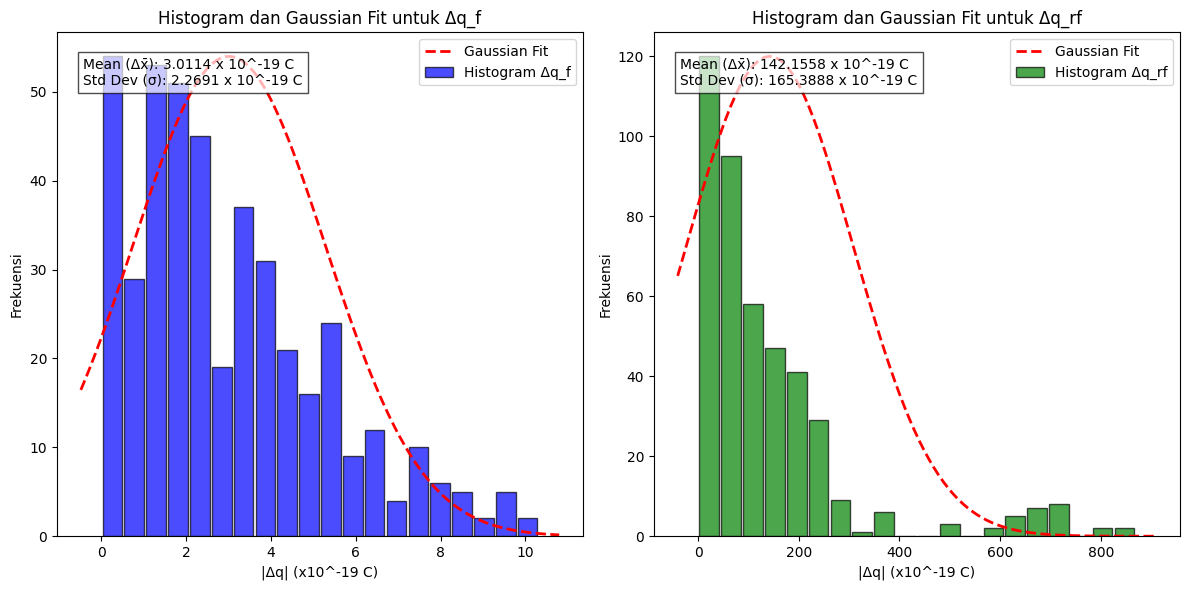

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm # Import fungsi norm untuk distribusi normal

# Data q_f (floating method) in units of 10^-19 C
q_f = [ 4.6946, 3.0064, 8.3033, 12.3651, 7.1738, 5.3248, 6.8461, 4.6049, 12.6973, 3.5267,
    9.1980, 6.8565, 6.9325, 8.0171, 4.9537, 4.9759, 7.0323, 13.2794, 6.9465, 6.9759,
    9.4089, 8.0103, 2.9684, 10.2712, 6.0691, 8.9615, 8.2655, 5.4294, 8.5158, 4.9769
]

# Data q_rf (falling and rising method) in units of 10^-19 C
q_rf = [ 974.5146, 105.5517, 322.4902, 485.5693, 248.3957,
    257.4193, 296.6352, 191.5361, 492.2173, 189.3556,
    324.4291, 283.8970, 279.8558, 338.5580, 264.5881,
    275.3537, 287.0108, 495.4506, 317.0052, 301.9930,
    241.2547, 364.6110, 109.8027, 378.0310, 261.9246,
    326.7481, 363.8202, 269.2236, 382.6751, 241.5523
]

# Function to calculate mean manually
def mean(data):
    total = 0
    for x in data:
        total += x
    return total / len(data)

# Function to calculate standard deviation manually (sample standard deviation)
def std_dev(data):
    m = mean(data)
    variance_sum = 0
    for x in data:
        variance_sum += (x - m) ** 2
    if len(data) <= 1: # Handle case with 0 or 1 data point
        return 0
    variance = variance_sum / (len(data) - 1)
    return variance ** 0.5

# Calculate all absolute differences for q_f
selisih_qf = []
for i in range(len(q_f)):
    for j in range(i+1, len(q_f)):
        selisih_qf.append(abs(q_f[i] - q_f[j]))

# Calculate all absolute differences for q_rf
selisih_qrf = []
for i in range(len(q_rf)):
    for j in range(i+1, len(q_rf)):
        selisih_qrf.append(abs(q_rf[i] - q_rf[j]))

# Calculate mean and std dev for the differences
mean_qf = mean(selisih_qf)
std_qf = std_dev(selisih_qf)

mean_qrf = mean(selisih_qrf)
std_qrf = std_dev(selisih_qrf)

# Function to create histogram data manually
def create_histogram(data, bins):
    if not data: # Handle empty data list
        return [], []
    min_val = min(data)
    max_val = max(data)
    if min_val == max_val: # Handle case where all values are the same
        return [len(data)], [min_val, max_val] # Single bin
    bin_width = (max_val - min_val) / bins
    counts = [0] * bins
    for d in data:
        # Find bin index
        idx = int((d - min_val) / bin_width)
        if idx == bins:  # edge case for max value
            idx -= 1
        counts[idx] += 1
    bin_edges = [min_val + i * bin_width for i in range(bins + 1)]
    return counts, bin_edges

# Create histograms
bins = 20
counts_qf, bins_qf = create_histogram(selisih_qf, bins)
counts_qrf, bins_qrf = create_histogram(selisih_qrf, bins)

# Plotting
plt.figure(figsize=(12, 6))

# Plot for q_f
plt.subplot(1, 2, 1)
if bins_qf: # Check if bins were created (data is not empty)
    bin_centers_qf = [(bins_qf[i] + bins_qf[i+1]) / 2 for i in range(len(bins_qf)-1)]
    plt.bar(bin_centers_qf, counts_qf, width=(bins_qf[1]-bins_qf[0])*0.9, color='blue', edgecolor='black', alpha=0.7, label='Histogram Δq_f')

    # Plot Gaussian fit for q_f differences
    xmin_qf, xmax_qf = plt.xlim()
    x_qf = np.linspace(xmin_qf, xmax_qf, 100)
    p_qf = norm.pdf(x_qf, mean_qf, std_qf)
    # Scale the PDF to match the histogram height
    max_hist_qf = max(counts_qf) if counts_qf else 0
    max_pdf_qf = norm.pdf(mean_qf, mean_qf, std_qf) if std_qf > 0 else 0
    if max_pdf_qf > 0:
        scale_qf = max_hist_qf / max_pdf_qf
        plt.plot(x_qf, p_qf * scale_qf, 'r--', linewidth=2, label='Gaussian Fit')

plt.title('Histogram dan Gaussian Fit untuk Δq_f')
plt.xlabel('|Δq| (x10^-19 C)')
plt.ylabel('Frekuensi')
plt.text(0.05, 0.95, f'Mean (Δx̄): {mean_qf:.4f} x 10^-19 C\nStd Dev (σ): {std_qf:.4f} x 10^-19 C',
         transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))
plt.legend() # Show legend to differentiate histogram and fit

# Plot for q_rf
plt.subplot(1, 2, 2)
if bins_qrf: # Check if bins were created
    bin_centers_qrf = [(bins_qrf[i] + bins_qrf[i+1]) / 2 for i in range(len(bins_qrf)-1)]
    plt.bar(bin_centers_qrf, counts_qrf, width=(bins_qrf[1]-bins_qrf[0])*0.9, color='green', edgecolor='black', alpha=0.7, label='Histogram Δq_rf')

    # Plot Gaussian fit for q_rf differences
    xmin_qrf, xmax_qrf = plt.xlim()
    x_qrf = np.linspace(xmin_qrf, xmax_qrf, 100)
    p_qrf = norm.pdf(x_qrf, mean_qrf, std_qrf)
    # Scale the PDF to match the histogram height
    max_hist_qrf = max(counts_qrf) if counts_qrf else 0
    max_pdf_qrf = norm.pdf(mean_qrf, mean_qrf, std_qrf) if std_qrf > 0 else 0
    if max_pdf_qrf > 0:
        scale_qrf = max_hist_qrf / max_pdf_qrf
        plt.plot(x_qrf, p_qrf * scale_qrf, 'r--', linewidth=2, label='Gaussian Fit')


plt.title('Histogram dan Gaussian Fit untuk Δq_rf')
plt.xlabel('|Δq| (x10^-19 C)')
plt.ylabel('Frekuensi')
plt.text(0.05, 0.95, f'Mean (Δx̄): {mean_qrf:.4f} x 10^-19 C\nStd Dev (σ): {std_qrf:.4f} x 10^-19 C',
         transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))
plt.legend() # Show legend

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00


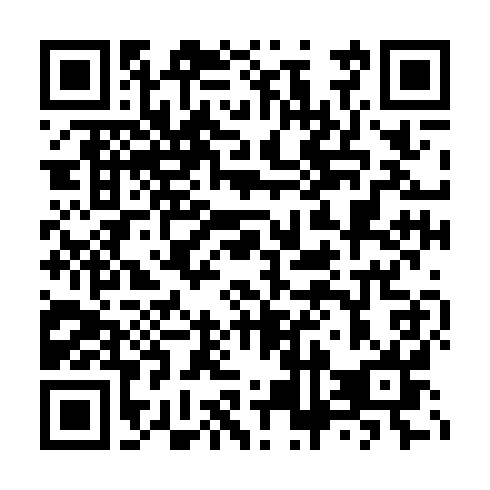

In [ ]:
# Install library qrcode
!pip install qrcode[pil]

# Import library
import qrcode
from IPython.display import Image, display

# Ganti URL di bawah ini dengan link Google Colab yang kamu inginkan
link = "https://colab.research.google.com/drive/1B-EavjBq8OELuHyftAnpn_wFh6hMPCyY#scrollTo=j6NolJLZgNOm"

# Buat QR code
qr = qrcode.make(link)

# Tampilkan QR code
qr.save("qrcode_colab.png")
display(Image(filename="qrcode_colab.png"))
